# 6CS012 - Tutorial 7
## Denoising Convolutional Autoencoder — Devnagari Handwritten Digit Dataset



## Step 0: Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import tensorflow as tf
print(tf.__version__)


2.15.0


---
## Step 1: Load and Preprocess the Devnagari Dataset



In [2]:

DATASET_PATH = "DevanagariHandwrittenDigitDataset"   
IMG_SIZE     = (32, 32)   # Devnagari images are 32x32
IMG_SHAPE    = (32, 32, 1)
MAX_IMAGES   = 10000      

def load_images_from_folder(root_folder, img_size, max_images=None):
    """
    Recursively loads grayscale images from all class subfolders.
    Returns a float32 numpy array normalised to [0, 1].
    """
    images = []
    for class_folder in sorted(os.listdir(root_folder)):
        class_path = os.path.join(root_folder, class_folder)
        if not os.path.isdir(class_path):
            continue
        for fname in os.listdir(class_path):
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img_path = os.path.join(class_path, fname)
            try:
                img = Image.open(img_path).convert('L')          # grayscale
                img = img.resize(img_size, Image.LANCZOS)
                images.append(np.array(img, dtype='float32') / 255.0)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")
            if max_images and len(images) >= max_images:
                return np.array(images)
    return np.array(images)

# Load train and test images
print("Loading training images...")
x_train_raw = load_images_from_folder(
    os.path.join(DATASET_PATH, 'Train'), IMG_SIZE, MAX_IMAGES
)
print(f"  Loaded {len(x_train_raw)} training images")

print("Loading test images...")
x_test_raw = load_images_from_folder(
    os.path.join(DATASET_PATH, 'Test'), IMG_SIZE, max_images=2000
)
print(f"  Loaded {len(x_test_raw)} test images")

# Add channel dimension: (N, 32, 32) -> (N, 32, 32, 1)
x_train_raw = x_train_raw.reshape(-1, *IMG_SHAPE)
x_test_raw  = x_test_raw.reshape(-1, *IMG_SHAPE)

print(f"\nTrain shape : {x_train_raw.shape}")
print(f"Test  shape : {x_test_raw.shape}")

Loading training images...
  Loaded 10000 training images
Loading test images...
  Loaded 2000 test images

Train shape : (10000, 32, 32, 1)
Test  shape : (2000, 32, 32, 1)


---
## Step 2: Add Gaussian Noise

In [3]:
def add_gaussian_noise(images, noise_factor):
    """
    Adds Gaussian noise and clips values to [0, 1].
    noise_factor controls the noise intensity.
    """
    noise = noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = images + noise
    return np.clip(noisy, 0.0, 1.0).astype('float32')

NOISE_FACTOR = 0.5   # as specified in the tutorial

x_train_noisy = add_gaussian_noise(x_train_raw, NOISE_FACTOR)
x_test_noisy  = add_gaussian_noise(x_test_raw,  NOISE_FACTOR)

print(f"Noisy train shape : {x_train_noisy.shape}")
print(f"Pixel range       : [{x_train_noisy.min():.2f}, {x_train_noisy.max():.2f}]")

Noisy train shape : (10000, 32, 32, 1)
Pixel range       : [0.00, 1.00]


### Visualise: Original vs Noisy Images

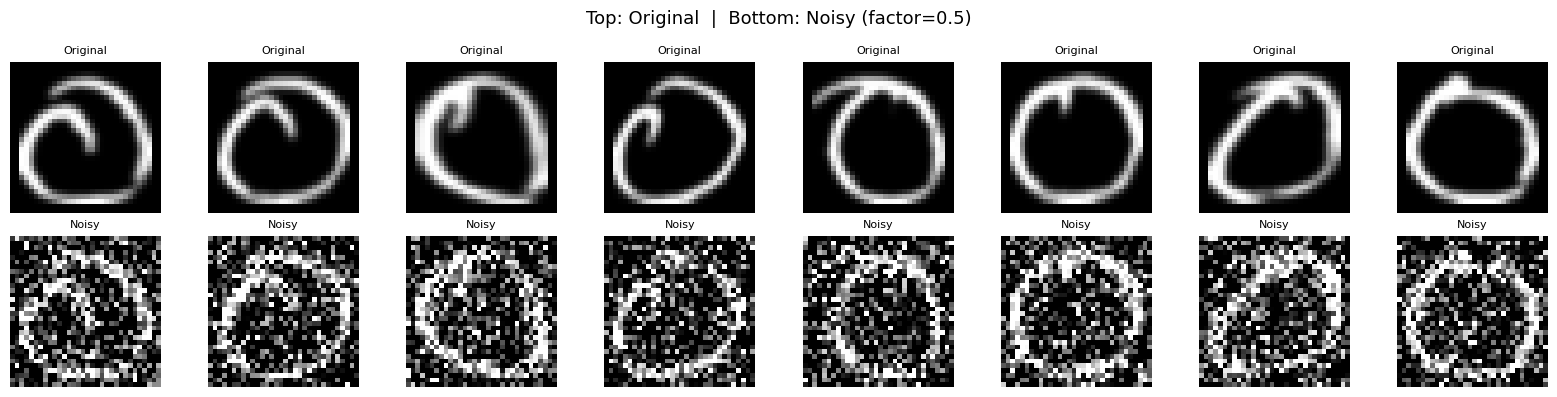

In [4]:
n = 8
fig, axes = plt.subplots(2, n, figsize=(16, 4))
fig.suptitle("Top: Original  |  Bottom: Noisy (factor=0.5)", fontsize=13)

for i in range(n):
    axes[0, i].imshow(x_train_raw[i].reshape(IMG_SIZE), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('Original', fontsize=8)

    axes[1, i].imshow(x_train_noisy[i].reshape(IMG_SIZE), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('Noisy', fontsize=8)

plt.tight_layout()
plt.show()

---
## Step 3: Build the Denoising Convolutional Autoencoder

Architecture overview (≥ 4 conv layers, mirrored encoder–decoder):

```
ENCODER                               DECODER
Input 32×32×1                         ↑
Conv2D(32)  → 32×32×32               Conv2D(32)  → 32×32×32
MaxPool     → 16×16×32               UpSampling  → 32×32×32
Conv2D(64)  → 16×16×64               Conv2D(64)  → 16×16×64
MaxPool     → 8×8×64                 UpSampling  → 16×16×64
Conv2D(128) → 8×8×128                Conv2D(128) → 8×8×128
MaxPool     → 4×4×128    ←latent→    UpSampling  → 4×4×128
                                      Conv2D(1, sigmoid) → 32×32×1
```

In [5]:
def build_encoder(input_shape):
    """
    3 Conv+Pool stages → latent space at 4×4×128.
    Returns (input_tensor, encoded_tensor).
    """
    inp = Input(shape=input_shape, name='input')

    # --- Block 1 ---
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)   # 16×16×32

    # --- Block 2 ---
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)   # 8×8×64

    # --- Block 3 ---
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='enc_conv3')(x)
    x = BatchNormalization()(x)
    encoded = MaxPooling2D((2, 2), padding='same', name='latent')(x) # 4×4×128

    return inp, encoded


def build_decoder(encoded):
    """
    Mirror of the encoder: 3 UpSample+Conv stages back to original size.
    Returns reconstructed output tensor.
    """
    # --- Block 3 mirror ---
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name='dec_conv3')(encoded)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2), name='dec_up3')(x)                     # 8×8×128

    # --- Block 2 mirror ---
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2), name='dec_up2')(x)                     # 16×16×64

    # --- Block 1 mirror ---
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='dec_conv1')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2), name='dec_up1')(x)                     # 32×32×32

    # --- Output layer (sigmoid keeps pixels in [0,1]) ---
    decoded = Conv2D(1, (3, 3), activation='sigmoid',
                     padding='same', name='output')(x)               # 32×32×1
    return decoded


def build_autoencoder(input_shape):
    inp, encoded = build_encoder(input_shape)
    decoded      = build_decoder(encoded)
    autoencoder  = Model(inputs=inp, outputs=decoded, name='denoising_autoencoder')
    autoencoder.compile(optimizer=Adam(learning_rate=1e-3),
                        loss='binary_crossentropy')
    return autoencoder


autoencoder = build_autoencoder(IMG_SHAPE)
autoencoder.summary()



Model: "denoising_autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 32, 32, 1)]       0         
                                                                 
 enc_conv1 (Conv2D)          (None, 32, 32, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 enc_pool1 (MaxPooling2D)    (None, 16, 16, 32)        0         
                                                                 
 enc_conv2 (Conv2D)          (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 16, 16, 64)        256       
 chNormalization)                          

---
## Step 4: Train the Autoencoder

In [6]:
# Callbacks for smarter training
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

history = autoencoder.fit(
    x_train_noisy, x_train_raw,          # noisy input → clean target
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_raw),
    callbacks=[early_stop, reduce_lr]
)

print("\nTraining complete!")

Epoch 1/30

79/79 [==============================] - 12s 119ms/step - loss: 0.3700 - val_loss: 0.5345 - lr: 0.0010
Epoch 2/30
79/79 [==============================] - 9s 116ms/step - loss: 0.2030 - val_loss: 0.6357 - lr: 0.0010
Epoch 3/30
79/79 [==============================] - 9s 114ms/step - loss: 0.1717 - val_loss: 1.2159 - lr: 0.0010
Epoch 4/30
78/79 [============================>.] - ETA: 0s - loss: 0.1619
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
79/79 [==============================] - 9s 117ms/step - loss: 0.1619 - val_loss: 1.0713 - lr: 0.0010
Epoch 5/30
79/79 [==============================] - 9s 114ms/step - loss: 0.1560 - val_loss: 0.4613 - lr: 5.0000e-04
Epoch 6/30
79/79 [==============================] - 9s 114ms/step - loss: 0.1537 - val_loss: 0.2193 - lr: 5.0000e-04
Epoch 7/30
79/79 [==============================] - 9s 116ms/step - loss: 0.1524 - val_loss: 0.1709 - lr: 5.0000e-04
Epoch 8/30
79/79 [==============================] - 9s 

### Plot Training & Validation Loss

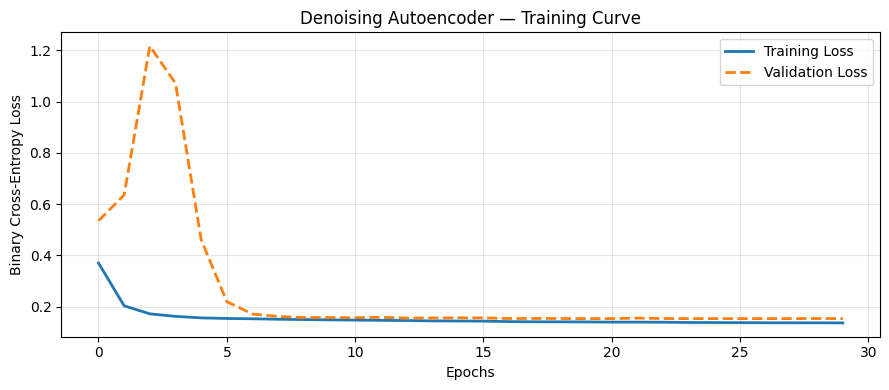

In [7]:
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'],     label='Training Loss',   linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Denoising Autoencoder — Training Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 5: Evaluate — Visualise Noisy → Denoised → Clean

Denoised output shape: (2000, 32, 32, 1)


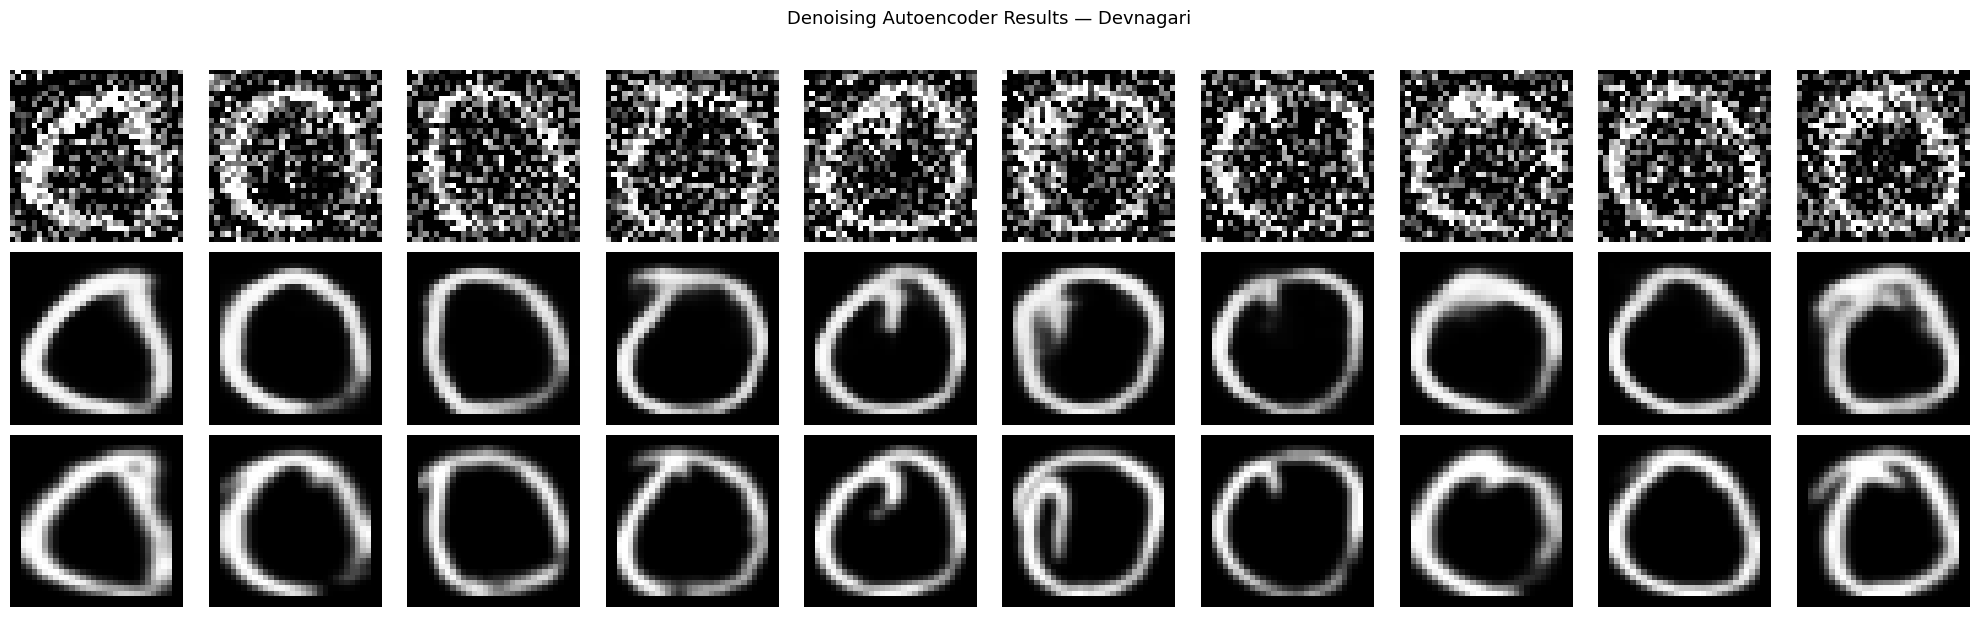

In [8]:
# Generate denoised predictions
denoised_images = autoencoder.predict(x_test_noisy, verbose=0)
print(f"Denoised output shape: {denoised_images.shape}")


def plot_comparison(noisy, denoised, clean, n=10, img_size=IMG_SIZE):
    """Displays n samples across 3 rows: Noisy | Denoised | Clean."""
    fig, axes = plt.subplots(3, n, figsize=(2 * n, 6))
    row_labels = ['Noisy Input', 'Denoised (AE)', 'Clean Original']
    data_rows  = [noisy, denoised, clean]

    for row, (label, data) in enumerate(zip(row_labels, data_rows)):
        axes[row, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=10)
        for col in range(n):
            axes[row, col].imshow(data[col].reshape(img_size), cmap='gray', vmin=0, vmax=1)
            axes[row, col].axis('off')

    plt.suptitle('Denoising Autoencoder Results — Devnagari', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


plot_comparison(x_test_noisy, denoised_images, x_test_raw, n=10)

---
## Step 6: Experiment — Effect of Noise Factor

Testing the same trained model against different noise levels to observe robustness.

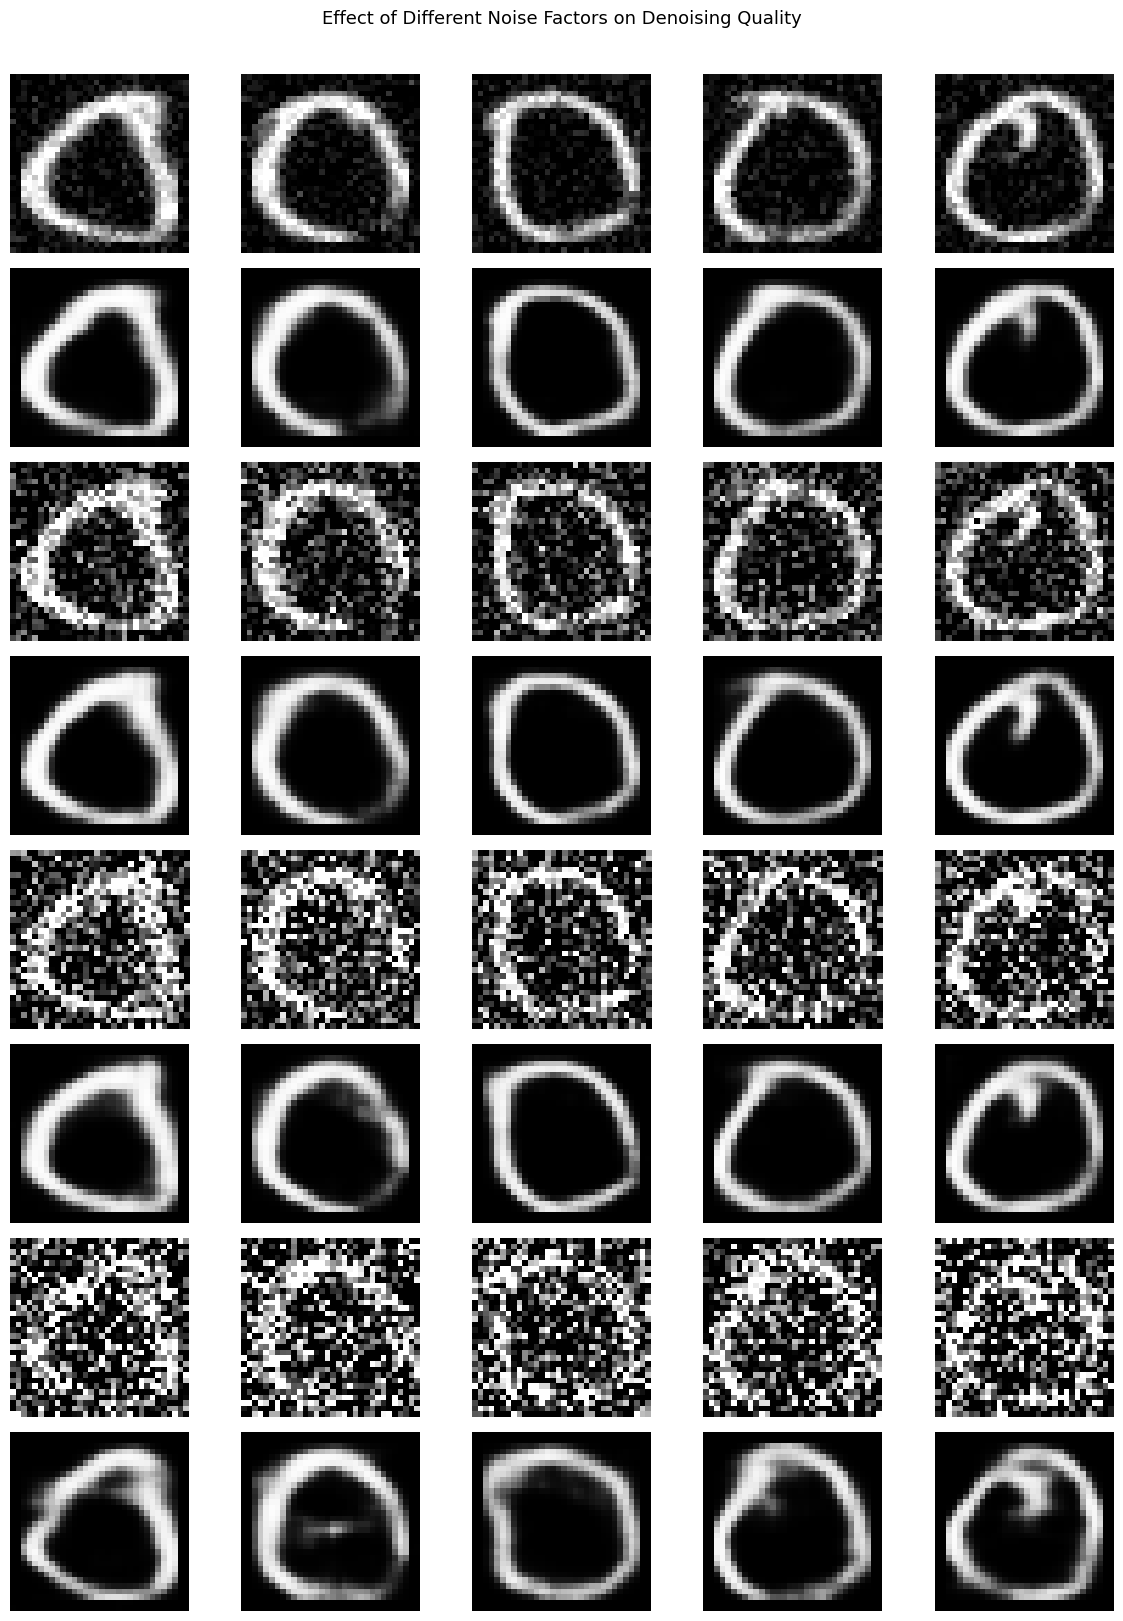

In [9]:
noise_levels = [0.1, 0.3, 0.5, 0.7]
n_samples    = 5

fig, axes = plt.subplots(len(noise_levels) * 2, n_samples, figsize=(12, 4 * len(noise_levels)))

for i, nf in enumerate(noise_levels):
    noisy_imgs    = add_gaussian_noise(x_test_raw[:n_samples], nf)
    denoised_imgs = autoencoder.predict(noisy_imgs, verbose=0)

    for j in range(n_samples):
        # Noisy row
        axes[i * 2, j].imshow(noisy_imgs[j].reshape(IMG_SIZE), cmap='gray', vmin=0, vmax=1)
        axes[i * 2, j].axis('off')
        if j == 0:
            axes[i * 2, j].set_ylabel(f'Noisy\n(factor={nf})', fontsize=9)

        # Denoised row
        axes[i * 2 + 1, j].imshow(denoised_imgs[j].reshape(IMG_SIZE), cmap='gray', vmin=0, vmax=1)
        axes[i * 2 + 1, j].axis('off')
        if j == 0:
            axes[i * 2 + 1, j].set_ylabel('Denoised', fontsize=9)

plt.suptitle('Effect of Different Noise Factors on Denoising Quality', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Step 7: Quantitative Evaluation — MSE per Noise Level

Noise=0.1 | MSE Noisy: 0.0058 | MSE Denoised: 0.0119 | Improvement: -104.2%
Noise=0.3 | MSE Noisy: 0.0479 | MSE Denoised: 0.0102 | Improvement: 78.7%
Noise=0.5 | MSE Noisy: 0.1160 | MSE Denoised: 0.0141 | Improvement: 87.9%
Noise=0.7 | MSE Noisy: 0.1799 | MSE Denoised: 0.0238 | Improvement: 86.8%


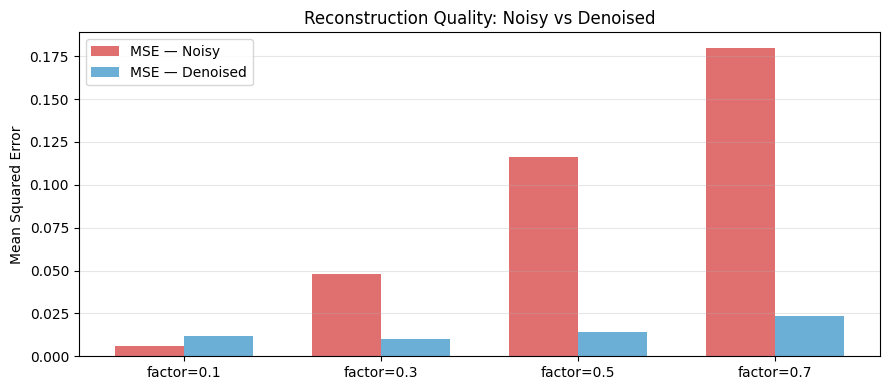

In [10]:
results = []

for nf in noise_levels:
    noisy       = add_gaussian_noise(x_test_raw, nf)
    denoised    = autoencoder.predict(noisy, verbose=0)
    mse_noisy   = np.mean((x_test_raw - noisy) ** 2)
    mse_denoised = np.mean((x_test_raw - denoised) ** 2)
    improvement = ((mse_noisy - mse_denoised) / mse_noisy) * 100
    results.append((nf, mse_noisy, mse_denoised, improvement))
    print(f"Noise={nf:.1f} | MSE Noisy: {mse_noisy:.4f} | "
          f"MSE Denoised: {mse_denoised:.4f} | "
          f"Improvement: {improvement:.1f}%")

# Bar chart
labels  = [f'factor={r[0]}' for r in results]
mse_n   = [r[1] for r in results]
mse_d   = [r[2] for r in results]
x_pos   = np.arange(len(labels))
width   = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x_pos - width/2, mse_n, width, label='MSE — Noisy',    color='#e07070')
ax.bar(x_pos + width/2, mse_d, width, label='MSE — Denoised', color='#6baed6')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel('Mean Squared Error')
ax.set_title('Reconstruction Quality: Noisy vs Denoised')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 8: Save the Model (Optional)

In [11]:
autoencoder.save('devnagari_denoising_autoencoder.h5')
print("Model saved to devnagari_denoising_autoencoder.h5")

Model saved to devnagari_denoising_autoencoder.h5


C:\Users\acer\Desktop\FInalYearAI\week7\tf_env\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


---
## Summary

| Component | Detail |
|-----------|--------|
| Dataset | Devnagari Handwritten Characters |
| Image size | 32×32×1 (grayscale) |
| Noise type | Gaussian (factor = 0.5) |
| Encoder layers | Conv2D(32) → Pool → Conv2D(64) → Pool → Conv2D(128) → Pool |
| Latent shape | 4×4×128 |
| Decoder layers | Conv2D(128) → Up → Conv2D(64) → Up → Conv2D(32) → Up → Conv2D(1, sigmoid) |
| Total conv layers | **6 encoder + 4 decoder = 10 conv layers** (well above ≥4 requirement) |
| Loss | Binary Cross-Entropy |
| Optimizer | Adam (lr=1e-3, with ReduceLROnPlateau) |
| Regularisation | BatchNormalization + EarlyStopping |
